# Scratch space for understanding spatial wavelets for image decompression
February 13, 2024


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [3]:
chromatin_model.create_deconvolution_bins(smoothing=False)

Unflattened the input data is of shape: (16, 15, 50)
The size of our input data, G is: (16, 750)


In [4]:
img0 = chromatin_model.deconv_hist_unflattened[0]
img1 = chromatin_model.deconv_hist_unflattened[1]

In [9]:
import pywt

def compress_image_with_wavelets(image, wavelet='bior4.4', threshold=0.01):
    # Perform wavelet decomposition
    coeffs = pywt.wavedec2(image, wavelet, level=1)

    coeffs_thresh = list(coeffs)
    for i in range(1, len(coeffs)):
        cH, cV, cD = coeffs[i]
#         coeffs_thresh[i] = (np.where(np.abs(cH) > threshold, cH, 0),
#                             np.where(np.abs(cV) > threshold, cV, 0),
#                             np.where(np.abs(cD) > threshold, cD, 0))

    return coeffs_thresh

coeffs0 = compress_image_with_wavelets(img0)
coeffs1 = compress_image_with_wavelets(img1)

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 1 is too high: all coefficients will experience boundary effects.
  warnings.warn(


In [10]:
def reconstruct_image_from_wavelets(coeffs):
    # Perform inverse wavelet transformation
    reconstructed_image = pywt.waverec2(coeffs, 'bior4.4')
    return reconstructed_image

# Assuming coeffs0 have been deconvolved or otherwise modified
reconstructed_img0 = reconstruct_image_from_wavelets(coeffs0)
reconstructed_img1 = reconstruct_image_from_wavelets(coeffs1)

In [12]:
# plt.figure(figsize=(6, 1))

# plt.subplot(2, 2, 1)
# plt.imshow(img0, cmap='magma_r', vmax=1, aspect='auto')
# plt.subplot(2, 2, 2)
# plt.imshow(img1, cmap='magma_r', vmax=1, aspect='auto')

# plt.subplot(2, 2, 3)
# plt.imshow(reconstructed_img0, cmap='magma_r', vmax=1, aspect='auto')
# plt.subplot(2, 2, 4)

# compressed_coeffs1 = compressed_coeffs1.copy()
# plt.imshow(reconstructed_img1, cmap='magma_r', vmax=1, aspect='auto')

In [13]:

def transform_coeffs_into_vector(coeffs):

    low_freq = coeffs[0].flatten()
    horizontal = coeffs[1][0].flatten()
    vertical = coeffs[1][0].flatten()
    diagonal = coeffs[1][0].flatten()
    
    flattend_coeffs = np.concatenate([low_freq, horizontal, vertical, diagonal])
    return flattend_coeffs

In [15]:

timepoints = chromatin_model.timepoints

G = None

for i in range(len(timepoints)):
    img = chromatin_model.deconv_hist_unflattened[i]
    coeffs = compress_image_with_wavelets(img)
    coeffs_flattened = transform_coeffs_into_vector(coeffs)
    
    if G is None:
        G = np.zeros((len(timepoints), len(coeffs_flattened)))
    
    G[i] = coeffs_flattened


In [16]:
G

array([[ 2.19350453,  1.06944594,  1.24356456, ..., -0.7951028 ,
        -0.38583609, -0.58011044],
       [ 5.75266547,  1.95700531,  1.92434461, ...,  0.76218436,
        -0.12111431,  0.32320257],
       [ 6.35012   ,  1.44947983,  3.38544663, ...,  1.5353236 ,
         0.78755914, -0.9437163 ],
       ...,
       [ 9.16081121,  2.48401446,  2.86260722, ..., -0.72650791,
        -0.39855123, -1.49338402],
       [ 7.84800699,  3.40284348,  4.5020844 , ...,  1.08581998,
         0.10073298, -0.94191281],
       [ 9.80656097,  4.25368447,  5.07599382, ...,  0.23864598,
         0.03528857, -0.95298305]])

In [55]:
from src.deconvolve_chromatin import deconvolve_chromatin_H

chromatin_model.setup_deconv_model()
deconv_model = chromatin_model.deconv_model

f, rn, sn = deconvolve_chromatin_H(deconv_model, deconv_model.H, subset_G, allow_negative=True,
    verbose=True, solver="MOSEK")

                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 13 04:47:21 PM: Your problem has 126666 variables, 0 constraints, and 0 parameters.
(CVXPY) Feb 13 04:47:21 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 13 04:47:21 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 13 04:47:21 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 13 04:47:21 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 13 04:47:21 PM: Compiling problem (target solver=MOSEK).

(CVXPY) Feb 13 04:48:14 PM: 26  3.4e-03  6.7e-03  2.9e-04  5.39e-01   4.423503949e+03   4.423507987e+03   3.4e-03  22.33 
(CVXPY) Feb 13 04:48:14 PM: 27  2.7e-03  5.4e-03  2.2e-04  5.35e-01   4.323678498e+03   4.323681872e+03   2.7e-03  22.60 
(CVXPY) Feb 13 04:48:14 PM: 28  2.3e-03  4.5e-03  1.8e-04  5.33e-01   4.251466447e+03   4.251469393e+03   2.3e-03  22.84 
(CVXPY) Feb 13 04:48:14 PM: 29  2.0e-03  4.0e-03  1.6e-04  5.27e-01   4.198585499e+03   4.198588161e+03   2.0e-03  23.12 
(CVXPY) Feb 13 04:48:15 PM: 30  1.6e-03  3.2e-03  1.2e-04  5.21e-01   4.113521017e+03   4.113523255e+03   1.6e-03  23.40 
(CVXPY) Feb 13 04:48:15 PM: 31  1.4e-03  2.8e-03  1.0e-04  5.14e-01   4.062987396e+03   4.062989409e+03   1.4e-03  23.79 
(CVXPY) Feb 13 04:48:15 PM: 32  1.1e-03  2.2e-03  7.8e-05  5.17e-01   3.967659039e+03   3.967660673e+03   1.1e-03  24.04 
(CVXPY) Feb 13 04:48:16 PM: 33  9.4e-04  1.9e-03  6.3e-05  5.39e-01   3.901067224e+03   3.901068626e+03   9.4e-04  24.28 
(CVXPY) Feb 13 04:48:16 

558


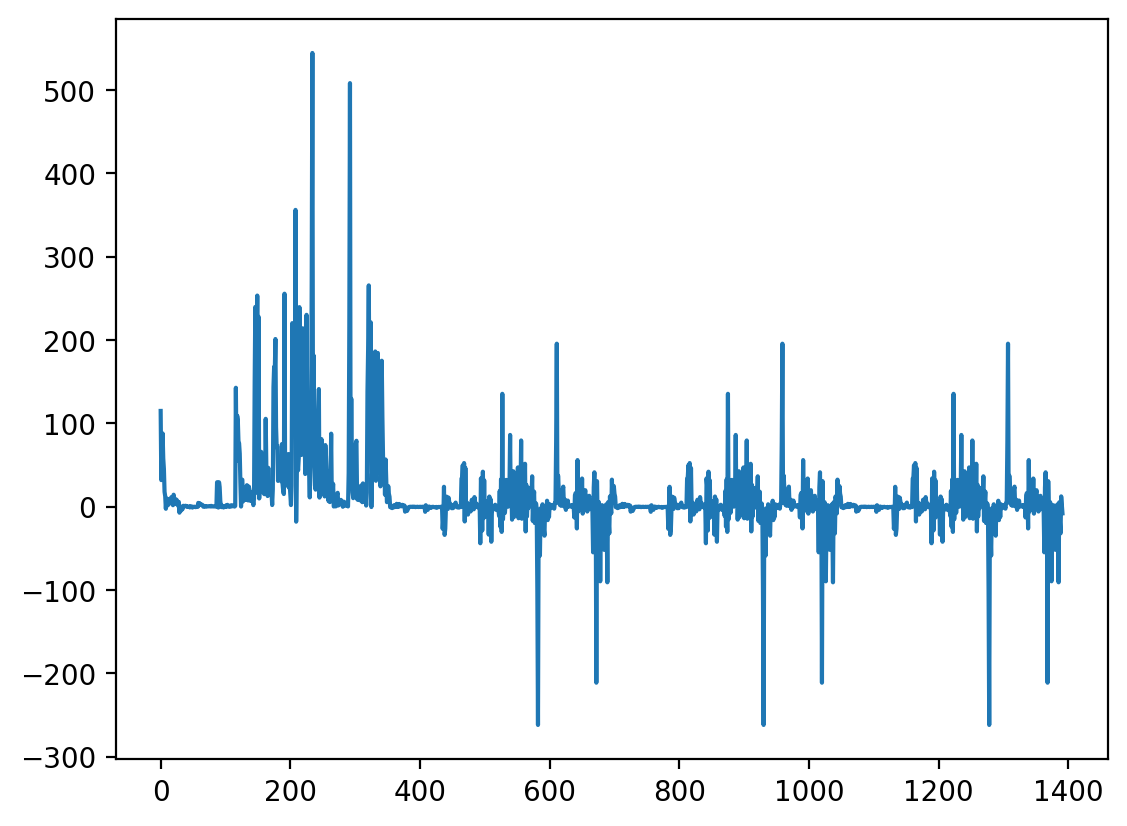

In [51]:
plt.plot(G.sum(axis=0))
# For some of the variables the data is not cycling and should be discarded

sel_G = (np.abs(G.sum(axis=0)) > 10)
print(sel_G.sum())
subset_G = G[:, sel_G]

In [105]:
# Construct the full f data
full_f = np.zeros((f.shape[0], G.shape[1]))
full_f[:, sel_G] = f

In [102]:

def transform_vector_into_coeffs(vec, orig_coeffs):

    # Get the low frequency coefficients
    low_freq_shape = orig_coeffs[0].shape
    low_freq_shape_len = low_freq_shape[0]*low_freq_shape[1]
    low_freq_coffs = vec[0:low_freq_shape_len]
    low_freq_coffs = low_freq_coffs.reshape(low_freq_shape)
    
    horizontal_shape = orig_coeffs[1][0].shape
    horizontal_indices = np.arange(low_freq_shape_len,
        low_freq_shape_len+horizontal_shape[0]*horizontal_shape[1])
    hor_coffs = vec[horizontal_indices]
    hor_coffs = hor_coffs.reshape(horizontal_shape)
    
    vertical_shape = coeffs[1][1].shape
    vertical_indices = np.arange(horizontal_indices[-1], 
        horizontal_indices[-1]+vertical_shape[0]*vertical_shape[1])
    vert_coffs = vec[vertical_indices]
    vert_coffs = vert_coffs.reshape(vertical_shape)
    
    diag_shape = coeffs[1][2].shape
    diag_indices = np.arange(vertical_indices[-1], 
        vertical_indices[-1]+diag_shape[0]*diag_shape[1])
    diag_coffs = vec[diag_indices]
    diag_coffs = diag_coffs.reshape(diag_shape)
    
    return (low_freq_coffs, (hor_coffs, vert_coffs, diag_coffs))

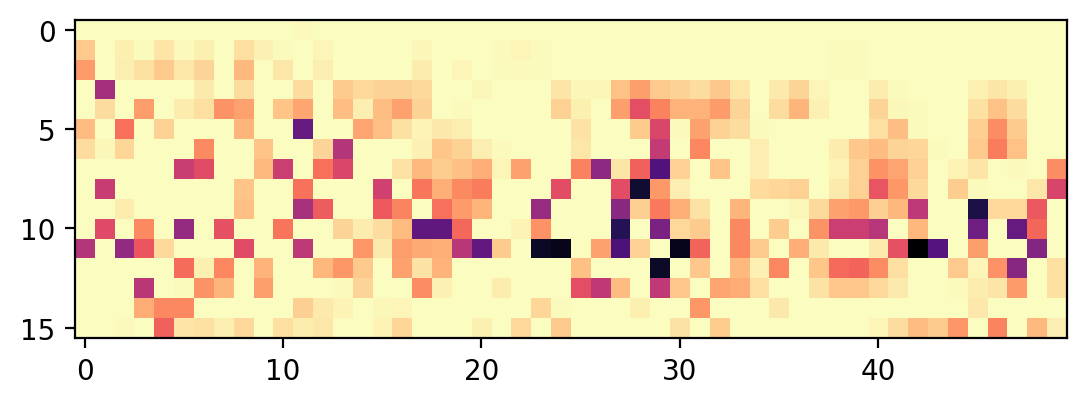

In [114]:


ind = 0

deconv_coeffs = transform_vector_into_coeffs(full_f[ind], coeffs)
reconstructed_img = reconstruct_image_from_wavelets(deconv_coeffs)
plt.imshow(reconstructed_img, cmap='magma_r', vmin=0)


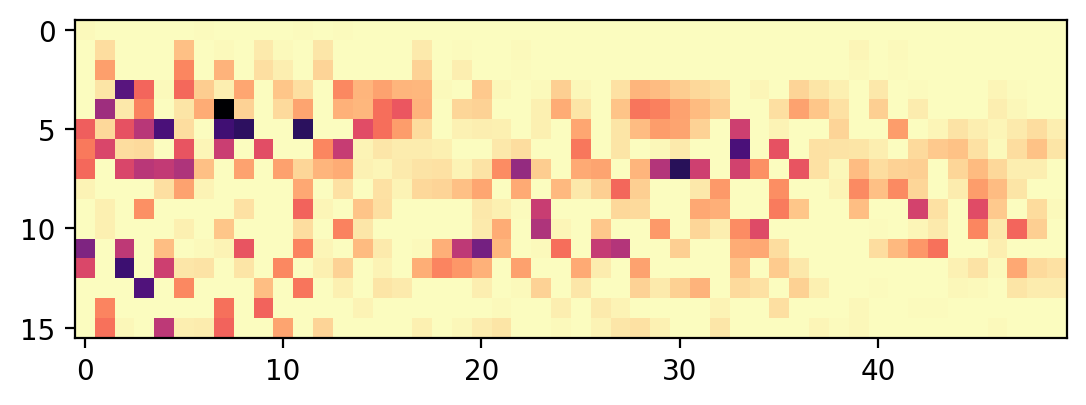

In [116]:


ind = 50

deconv_coeffs = transform_vector_into_coeffs(full_f[ind], coeffs)
reconstructed_img = reconstruct_image_from_wavelets(deconv_coeffs)
plt.imshow(reconstructed_img, cmap='magma_r', vmin=0)


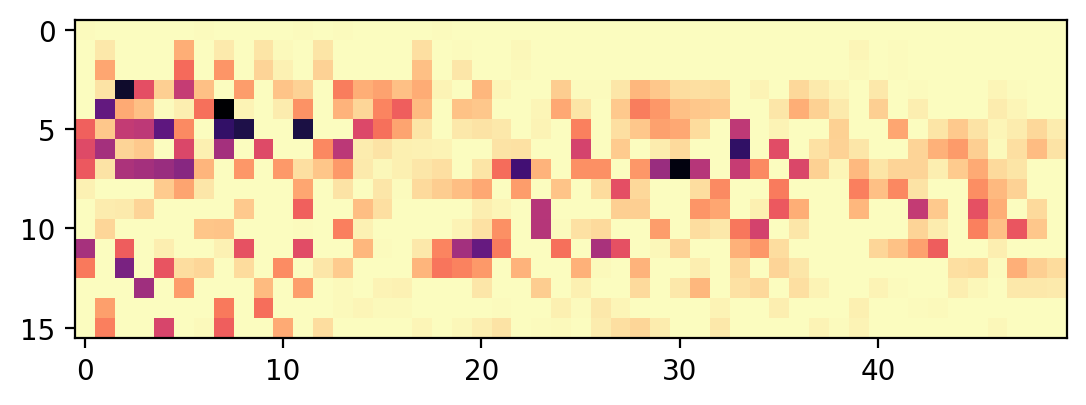

In [115]:


ind = 100

deconv_coeffs = transform_vector_into_coeffs(full_f[ind], coeffs)
reconstructed_img = reconstruct_image_from_wavelets(deconv_coeffs)
plt.imshow(reconstructed_img, cmap='magma_r', vmin=0)
